## Output Analysis



This is the same as Output_Analysis_1.1, except that here we calculate the Median of Efficacy instead of the Mean, so the outliers do not interfere so much.

- Tmax = 5000 generations
- Number of replicates = 1000 replicates
- Size of array = 40 spacers

In [1]:
import glob
import pandas as pd

def load_file(file_path):
    # Load the data, skipping the first 5 lines
    data = pd.read_csv(file_path, delim_whitespace=True, skiprows=5)
    data = data.iloc[:, :-1] # Remove the last column "(means)"
    return data

# Specify the folder path and file pattern
folder_path = "/Users/jimenamartinreina/Documents/MASTER/PRACTICAS_TFM/MODELO/OUTPUTS/210125/"

# esto hay que hacer las simulaciones con el simulatespacers1.2 y cargar los datos
file_pattern = "OutputFile_*.txt"

# Get a list of all files matching the pattern
file_paths = glob.glob(folder_path + file_pattern)
data_dict = {file_path: load_file(file_path) for file_path in file_paths}

# Verify data
#for file, data in data_dict.items():
#    print(f"Data for {file}:\n", data)


In [2]:
columns = next(iter(data_dict.values())).columns  # Get columns from the first DataFrame(with next and iter)
print(columns)

Index(['beta', 'age', 'efficacy', 'fitness', 'endemicBeta', 'epidemicBeta'], dtype='object')


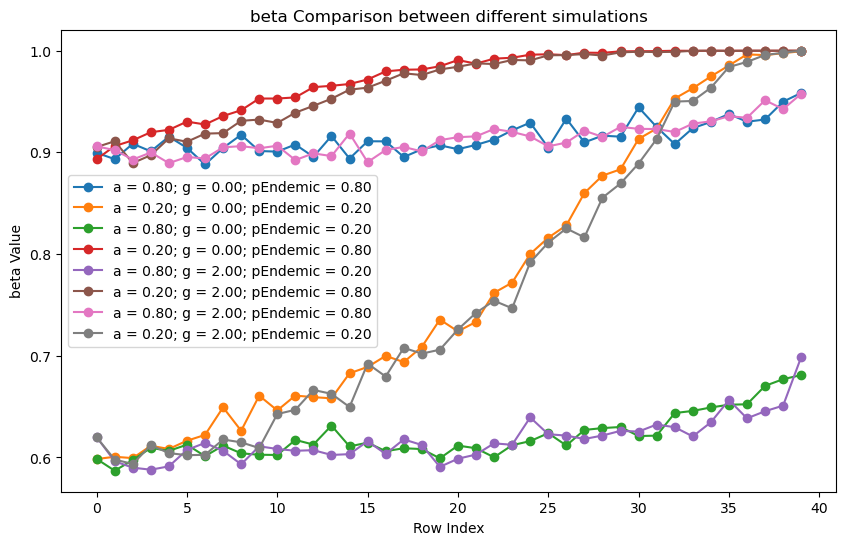

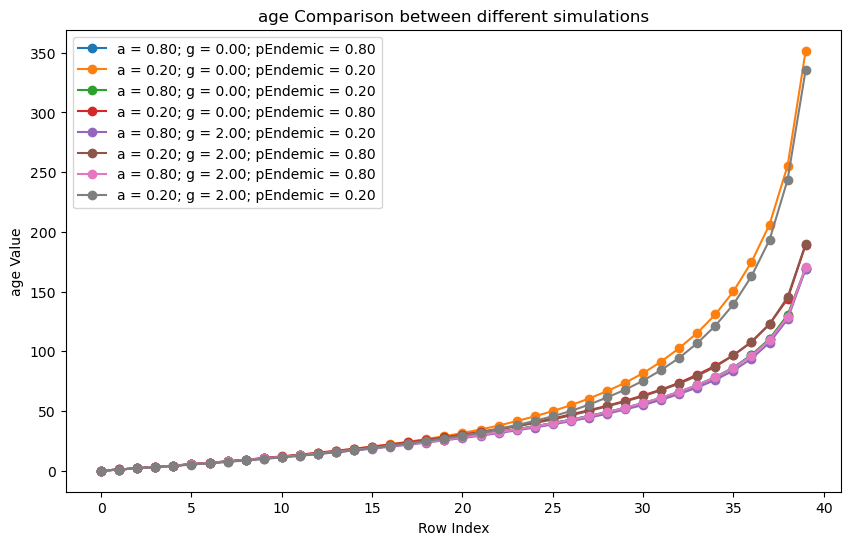

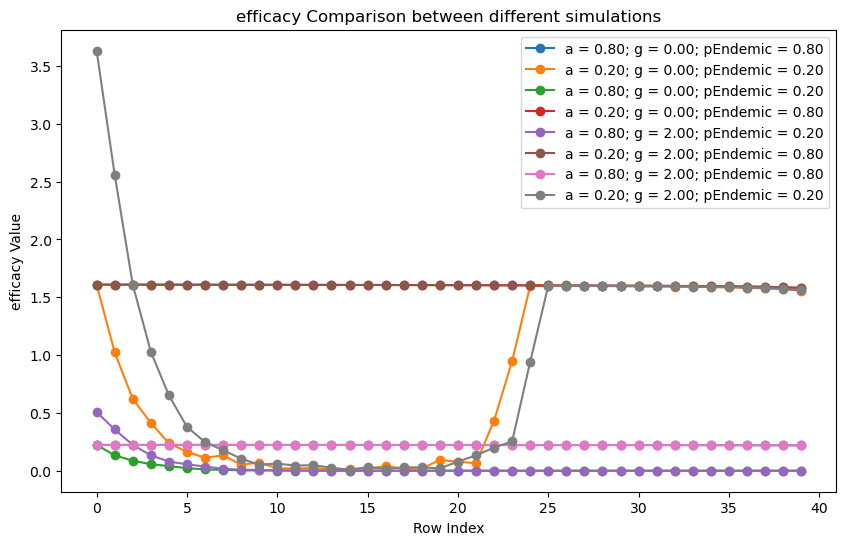

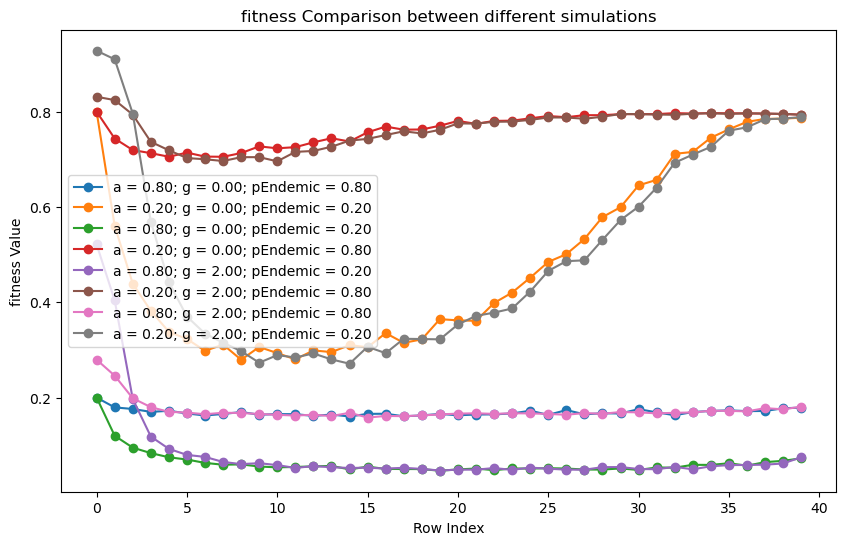

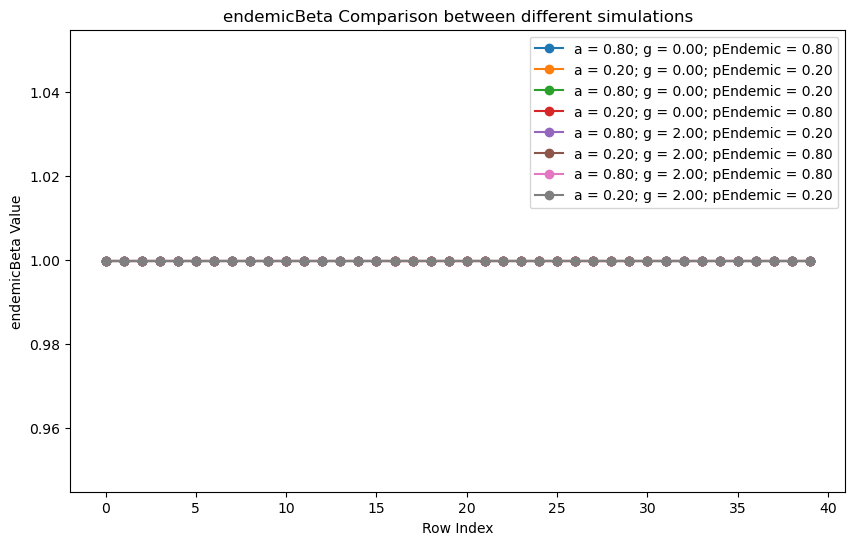

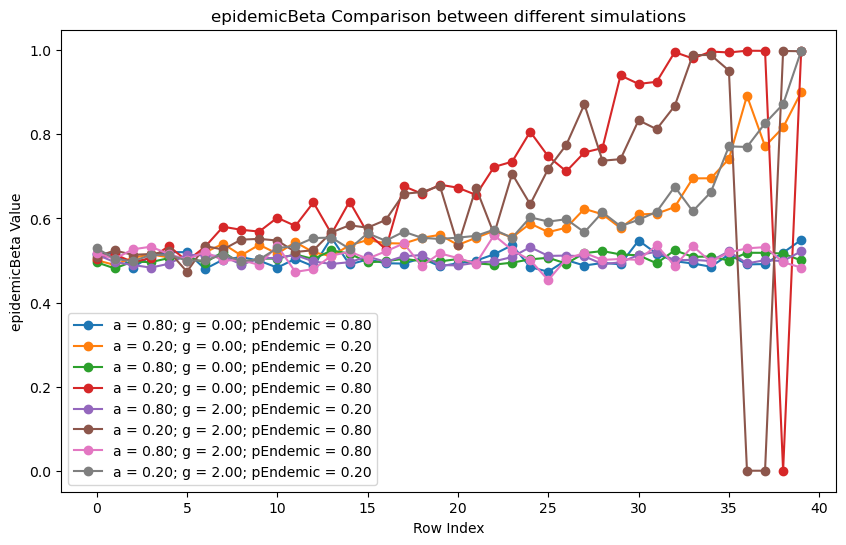

In [3]:
import matplotlib.pyplot as plt

# Extract parameter information from filenames for labeling
def extract_label(file_name):
    # Extract meaningful parts from the filename (modify based on your filename pattern)
    params = file_name.split("/")[-1].split("_")
    a = params[1]
    g = params[2]
    p_endemic = params[3].replace(".txt", "")
    return f'a = {a}; g = {g}; pEndemic = {p_endemic}'

# Loop over each column
for column in columns:
    plt.figure(figsize=(10, 6))
    
    # Loop over each file and plot the column's data
    for file_name, data in data_dict.items():
        label = extract_label(file_name)
        plt.plot(data.index, data[column], label=label, marker='o')
    
    # Adding title and labels
    plt.title(f'{column} Comparison between different simulations')
    plt.xlabel('Row Index')
    plt.ylabel(f'{column} Value')
    plt.legend()
    
    # Show the plot for the current column
    plt.show()


We observe the maxima on the left it is indeed the first point in all cases, but this doesn't happen with the maxima onn nthe right.
In 3 of this 8 cases, the fitness maxima was not in the last spacer. I believe this can happen due to the variability we find in the curve because of the number of replicates.

Maybe if we increase the number of replicates, the curves will be smoother, and the maximum will be in the last spacer.

### Ratio between maxima, position of minimum and FWHM (Full Width at Half Maximum)

File: /Users/jimenamartinreina/Documents/MASTER/PRÁCTICAS+TFM/MODELO/OUTPUTS/210125/OutputFile_0.80_0.00_0.80.txt
  Max Left: 0, Value Max Left: 0.2, Max Right: 39, Value Max Right: 0.179
  Ratio of Left to Right Peak: 1.1173
  Minpoint : 14, Value : 0.1603
  Midpoint Left: 0.1802, Midpoint Right: 0.1696
  Euclidean distance between midpoints: 32.0572


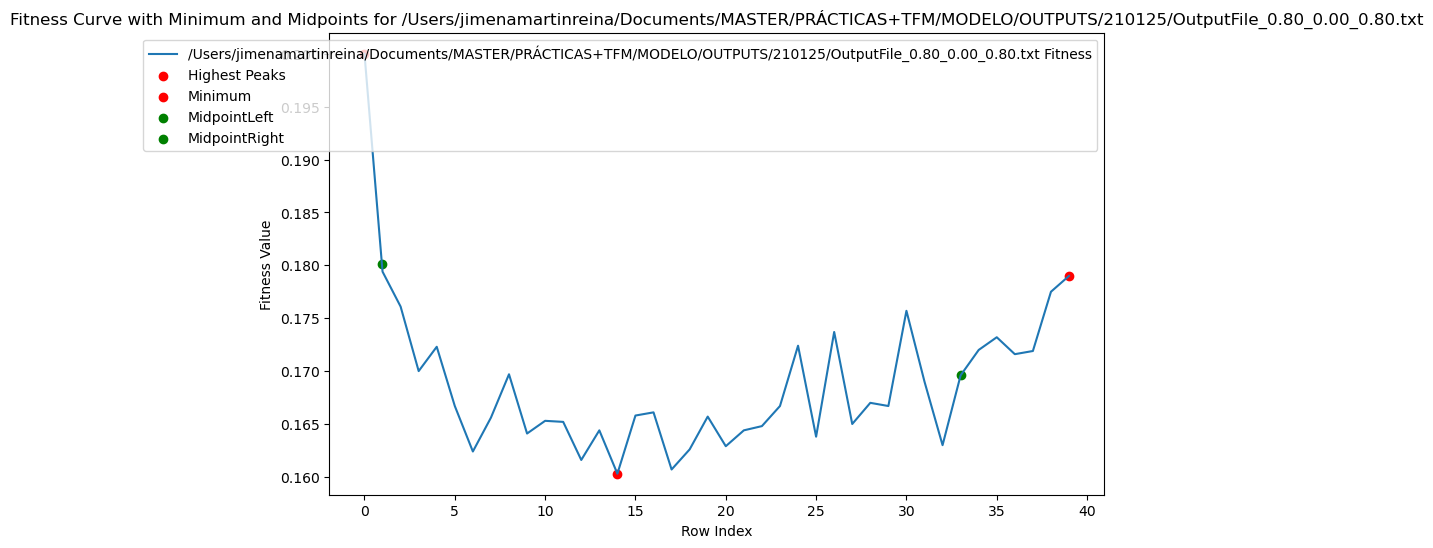

File: /Users/jimenamartinreina/Documents/MASTER/PRÁCTICAS+TFM/MODELO/OUTPUTS/210125/OutputFile_0.20_0.00_0.20.txt
  Max Left: 0, Value Max Left: 0.8, Max Right: 39, Value Max Right: 0.7874
  Ratio of Left to Right Peak: 1.0160
  Minpoint : 8, Value : 0.2794
  Midpoint Left: 0.5397, Midpoint Right: 0.5334
  Euclidean distance between midpoints: 25.8438


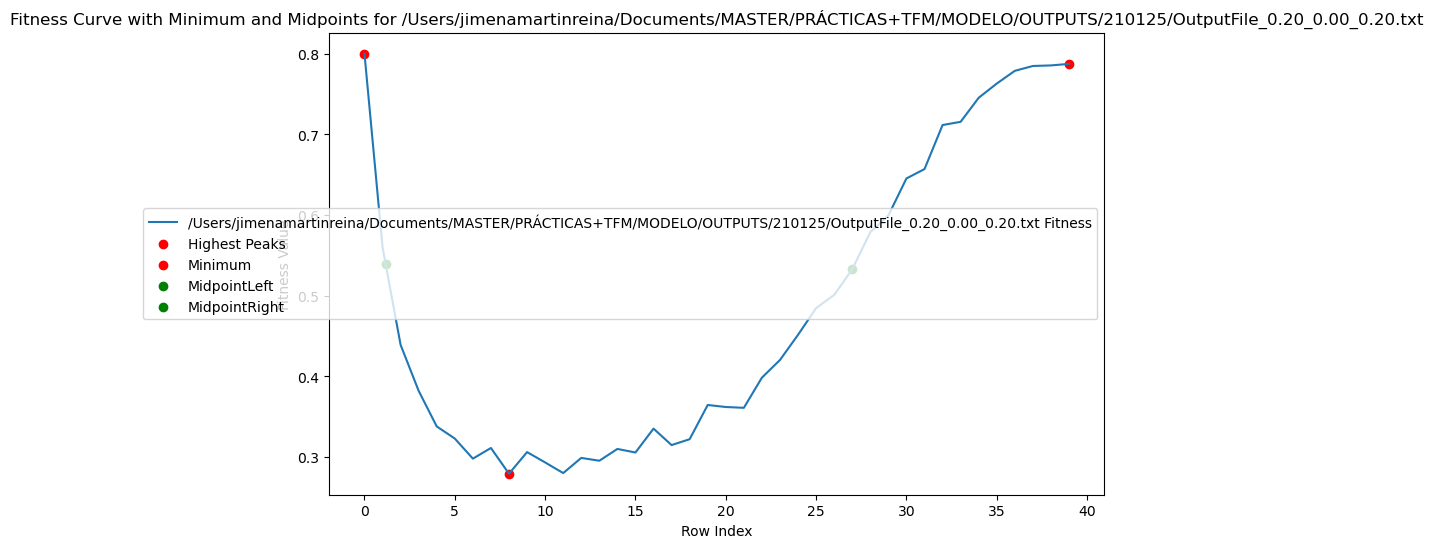

File: /Users/jimenamartinreina/Documents/MASTER/PRÁCTICAS+TFM/MODELO/OUTPUTS/210125/OutputFile_0.80_0.00_0.20.txt
  Max Left: 0, Value Max Left: 0.2, Max Right: 39, Value Max Right: 0.0725
  Ratio of Left to Right Peak: 2.7586
  Minpoint : 19, Value : 0.0465
  Midpoint Left: 0.1232, Midpoint Right: 0.0595
  Euclidean distance between midpoints: 35.3662


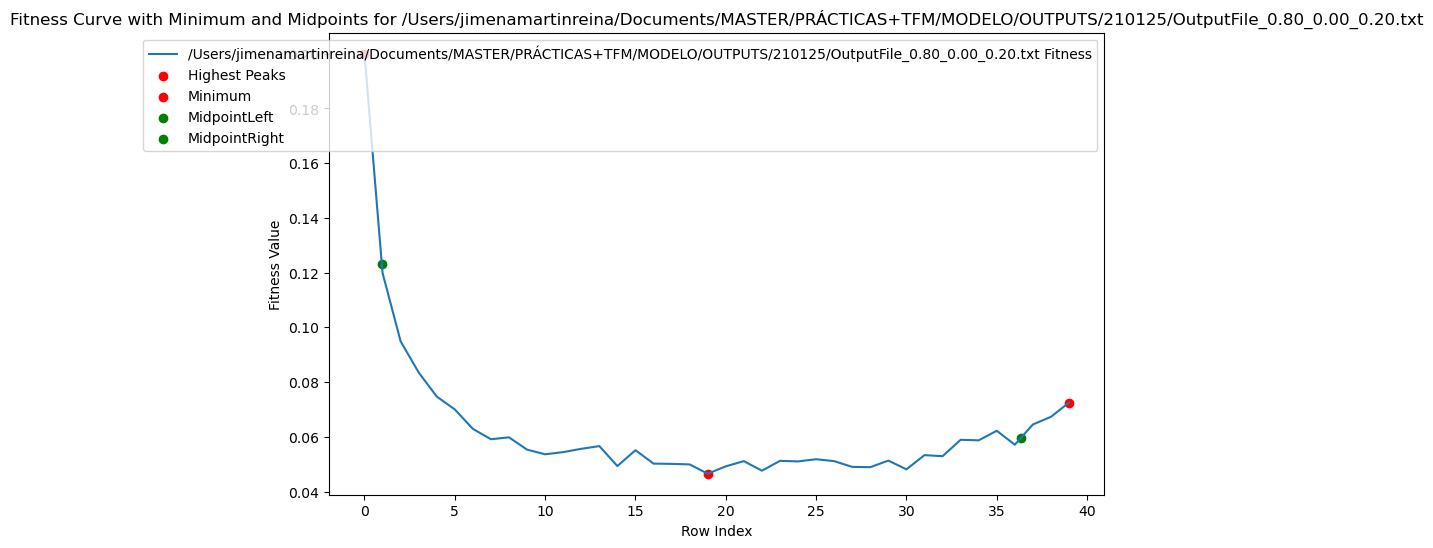

File: /Users/jimenamartinreina/Documents/MASTER/PRÁCTICAS+TFM/MODELO/OUTPUTS/210125/OutputFile_0.20_0.00_0.80.txt
  Max Left: 0, Value Max Left: 0.8, Max Right: 34, Value Max Right: 0.7971
  Ratio of Left to Right Peak: 1.0036
  Minpoint : 7, Value : 0.7054
  Midpoint Left: 0.7527, Midpoint Right: 0.7512
  Euclidean distance between midpoints: 13.8723


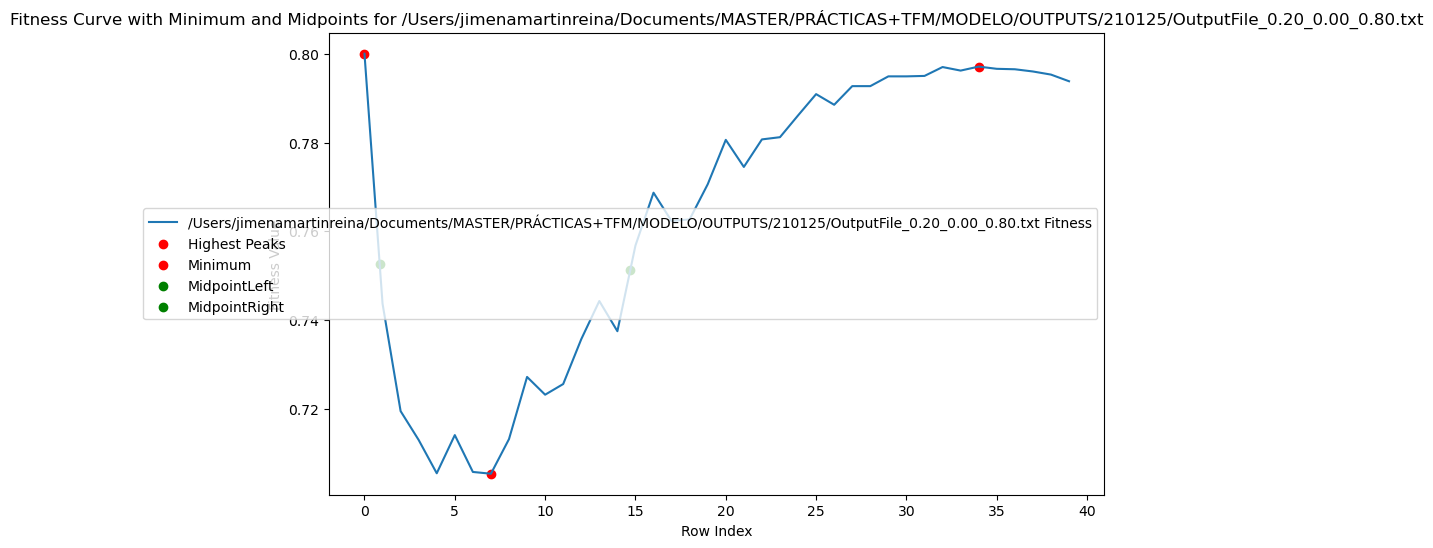

File: /Users/jimenamartinreina/Documents/MASTER/PRÁCTICAS+TFM/MODELO/OUTPUTS/210125/OutputFile_0.80_2.00_0.20.txt
  Max Left: 0, Value Max Left: 0.5214, Max Right: 39, Value Max Right: 0.0748
  Ratio of Left to Right Peak: 6.9706
  Minpoint : 19, Value : 0.0469
  Midpoint Left: 0.2842, Midpoint Right: 0.0609
  Euclidean distance between midpoints: 36.0819


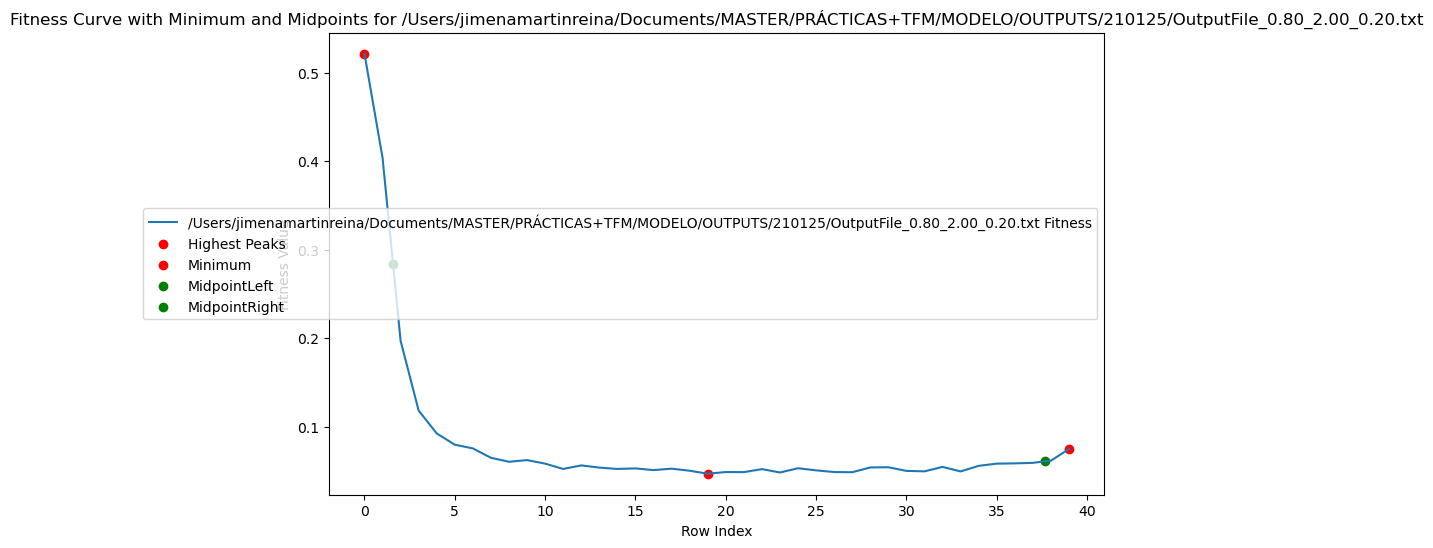

File: /Users/jimenamartinreina/Documents/MASTER/PRÁCTICAS+TFM/MODELO/OUTPUTS/210125/OutputFile_0.20_2.00_0.80.txt
  Max Left: 0, Value Max Left: 0.8313, Max Right: 34, Value Max Right: 0.7967
  Ratio of Left to Right Peak: 1.0434
  Minpoint : 10, Value : 0.6959
  Midpoint Left: 0.7636, Midpoint Right: 0.7463
  Euclidean distance between midpoints: 12.8819


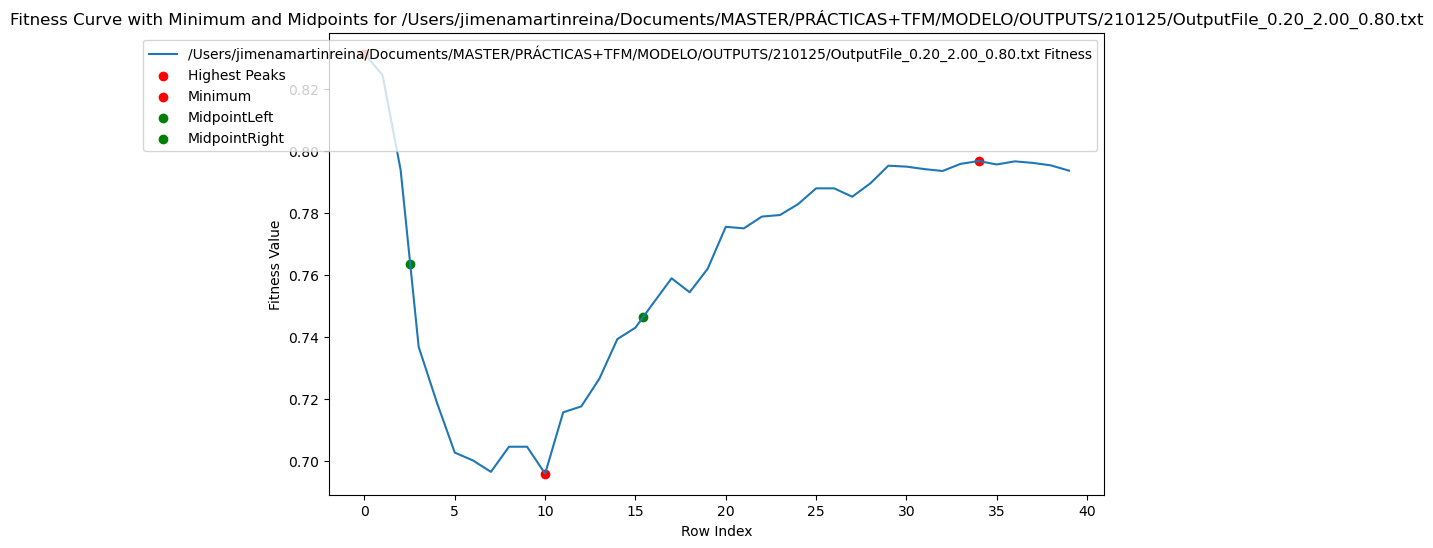

File: /Users/jimenamartinreina/Documents/MASTER/PRÁCTICAS+TFM/MODELO/OUTPUTS/210125/OutputFile_0.80_2.00_0.80.txt
  Max Left: 0, Value Max Left: 0.2795, Max Right: 39, Value Max Right: 0.1809
  Ratio of Left to Right Peak: 1.5451
  Minpoint : 15, Value : 0.1581
  Midpoint Left: 0.2188, Midpoint Right: 0.1695
  Euclidean distance between midpoints: 31.6154


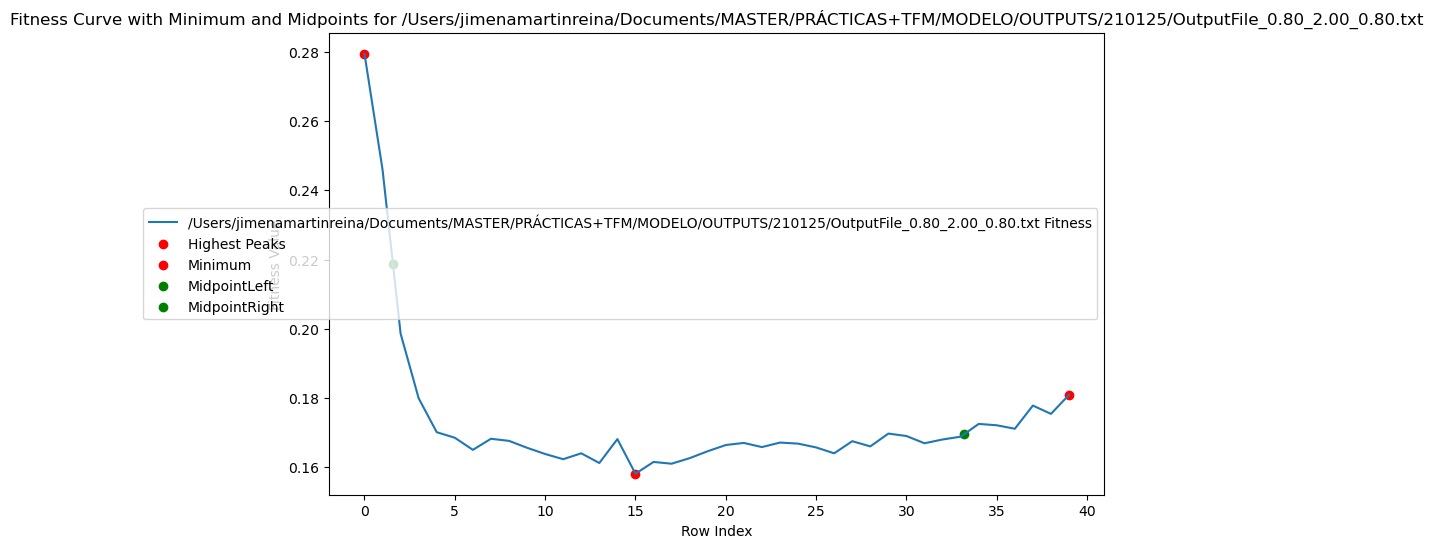

File: /Users/jimenamartinreina/Documents/MASTER/PRÁCTICAS+TFM/MODELO/OUTPUTS/210125/OutputFile_0.20_2.00_0.20.txt
  Max Left: 0, Value Max Left: 0.928, Max Right: 39, Value Max Right: 0.7888
  Ratio of Left to Right Peak: 1.1765
  Minpoint : 14, Value : 0.2711
  Midpoint Left: 0.5996, Midpoint Right: 0.5299
  Euclidean distance between midpoints: 25.1087


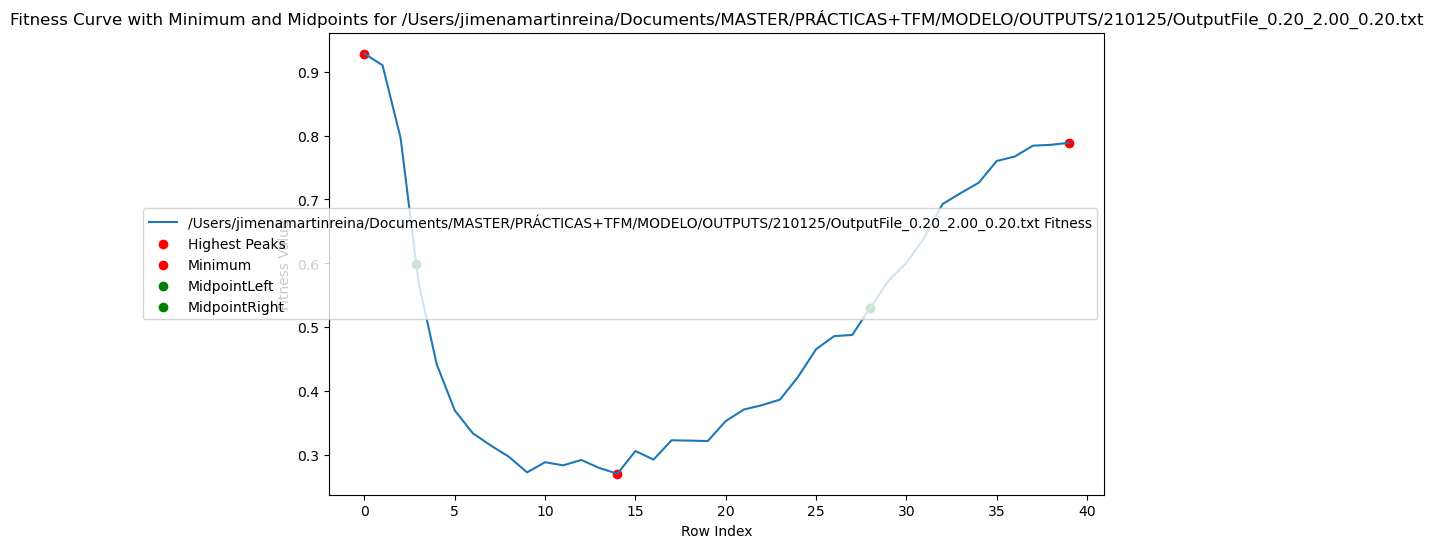

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
import glob
import numpy as np
import math 

# List all files matching the pattern (e.g., all .txt files in a directory)
file_paths = glob.glob("/Users/jimenamartinreina/Documents/MASTER/PRÁCTICAS+TFM/MODELO/OUTPUTS/210125/*.txt")

# Linear interpolation to find the index corresponding to the midpoint value
def find_interpolated_index(x_values, y_values, midpoint_value):
    # Perform linear interpolation to find the corresponding index
    for i in range(len(y_values) - 1):
        if (y_values[i] <= midpoint_value <= y_values[i + 1]) or (y_values[i] >= midpoint_value >= y_values[i + 1]):
            x_left = x_values[i]
            x_right = x_values[i + 1]
            y_left = y_values[i]
            y_right = y_values[i + 1]
            # Linear interpolation formula: y = y_left + (x - x_left) * (y_right - y_left) / (x_right - x_left)
            interpolated_x = x_left + (midpoint_value - y_left) * (x_right - x_left) / (y_right - y_left)
            return interpolated_x
    return None  # Return None if no interpolation was possible

def find_interpolated_index_reverse(x_values, y_values, midpoint_value):
    for i in range(len(y_values) - 1, 0, -1):
        if (y_values[i] <= midpoint_value <= y_values[i - 1]) or (y_values[i] >= midpoint_value >= y_values[i - 1]):
            x_right = x_values[i]
            x_left = x_values[i - 1]
            y_right = y_values[i]
            y_left = y_values[i - 1]
            
            # Linear interpolation formula: y = y_left + (x - x_left) * (y_right - y_left) / (x_right - x_left)
            interpolated_x = x_left + (midpoint_value - y_left) * (x_right - x_left) / (y_right - y_left)
            return interpolated_x
    return None  # Return None if no interpolation was possible

# Define a function to load the file and find the two highest peaks, including endpoints
def calculate_peak_ratio_including_endpoints(file_path):
    # Load the data, skipping the first 5 lines
    data = pd.read_csv(file_path, delim_whitespace=True, skiprows=5)
    # Extract the fitness column
    fitness = data['fitness']
    
    # Find the lowest peaks (minima) by inverting the fitness values
    minima, _ = find_peaks(-fitness, distance=10)  # Adjust `distance` as needed
    # Get the lowest minimum based on fitness values
    min_point = sorted(minima, key=lambda x: fitness[x])[:1]  # Sort to get the lowest minimum
    
    # Find peaks in the middle of the fitness data
    middle_peaks, _ = find_peaks(fitness, distance=10)
    # Include endpoints as potential maxima
    all_peaks = list(middle_peaks) + [0, len(fitness) - 1]  # Add indices for first and last points
    left_peaks = [p for p in all_peaks if p <= min_point[0]] # Peaks on the left of the minimum
    right_peaks = [p for p in all_peaks if p > min_point[0]] # On the right

    # Calculate the ratio between the two highest peaks
    if left_peaks and right_peaks:
        left_peak = max(left_peaks, key=lambda x: fitness[x])  
        right_peak = max(right_peaks, key=lambda x: fitness[x])  
        ratio = fitness[left_peak] / fitness[right_peak] if fitness[right_peak] != 0 else None
        return min_point, ratio, left_peak, right_peak, fitness[left_peak], fitness[right_peak]
    else:
        return None, None, None, None, None
    
# Loop over each file, calculate the minimum, midpoints, and plot the results
for file_path in file_paths:
    # Load fitness data again for plotting
    data = pd.read_csv(file_path, delim_whitespace=True, skiprows=5)
    fitness = data['fitness']
    x_values = np.arange(len(fitness))  # Create an array of x values (indices of the fitness array)

    # Calculate maxima
    min_point, ratio, left_peak, right_peak, left_peak_value, right_peak_value = calculate_peak_ratio_including_endpoints(file_path)

    # Calculate midpoints for left and right of the minimum
    midpoint_left = (fitness[min_point[0]] + left_peak_value) / 2
    midpoint_right = (fitness[min_point[0]] + right_peak_value) / 2
    
    # Find the indices of midpoints using interpolation
    midpoint_left_index = find_interpolated_index(x_values, fitness, midpoint_left) if midpoint_left is not None else None
    midpoint_right_index = find_interpolated_index_reverse(x_values, fitness, midpoint_right) if midpoint_right is not None else None
    # Calculate Euclidean distance between midpoints
    p = [midpoint_left_index, midpoint_left] 
    q = [midpoint_right_index, midpoint_right] 
    
    # Print the results
    print(f"File: {file_path}")
    print(f"  Max Left: {left_peak}, Value Max Left: {left_peak_value}, Max Right: {right_peak}, Value Max Right: {right_peak_value}")
    if ratio is not None:
        print(f"  Ratio of Left to Right Peak: {ratio:.4f}")
    else:
        print(f"File: {file_path} has an issue with the peak values; cannot calculate ratio.")
    print(f"  Minpoint : {min_point[0]}, Value : {fitness[min_point[0]]}")
    print(f"  Midpoint Left: {midpoint_left:.4f}, Midpoint Right: {midpoint_right:.4f}")
    print(f"  Euclidean distance between midpoints: {math.dist(p, q):.4f}")
    
    # Plotting the fitness curve with the marked minimum and midpoints
    plt.figure(figsize=(10, 6))
    plt.plot(fitness, label=f'{file_path} Fitness')
    
    # Plot maxima, minimum and midpoints (if valid)
    if left_peak is not None and right_peak is not None:
        plt.scatter([left_peak, right_peak], [fitness[left_peak], fitness[right_peak]], 
                    color='red', label='Highest Peaks')
    if min_point is not None:
        plt.scatter(min_point, fitness[min_point], color='red', label='Minimum')
    if midpoint_left is not None:
        plt.scatter(midpoint_left_index, midpoint_left, color='green', label='MidpointLeft')
    if midpoint_right is not None:
        plt.scatter(midpoint_right_index, midpoint_right, color='green', label='MidpointRight')

    plt.title(f"Fitness Curve with Minimum and Midpoints for {file_path}")
    plt.xlabel("Row Index")
    plt.ylabel("Fitness Value")
    plt.legend()
    plt.show()

### Using effective average to calculate the proportion of endemic-target spacers

In [5]:
# Initialize lists to store the beta values for each file
endemicBetas = []
epidemicBetas = []
betas = []

# Iterate over the dictionary to collect the 'endemicBeta', 'epidemicBeta', and 'beta' columns
for key, data in data_dict.items():
    endemicBetas.append(data['endemicBeta'])
    epidemicBetas.append(data['epidemicBeta'])
    betas.append(data['beta'])

# Keep results of fE (proportion of endemic-virus-target spacers in each position of the array)
fEs = []

# Calculate fE for each file
for i in range(len(data_dict)): 
    fE = (betas[i] - epidemicBetas[i]) / (endemicBetas[i] - epidemicBetas[i])
    fEs.append(fE)
#    print(f"fE for {list(data_dict.keys())[i]}:\n {fE}") #to verify results


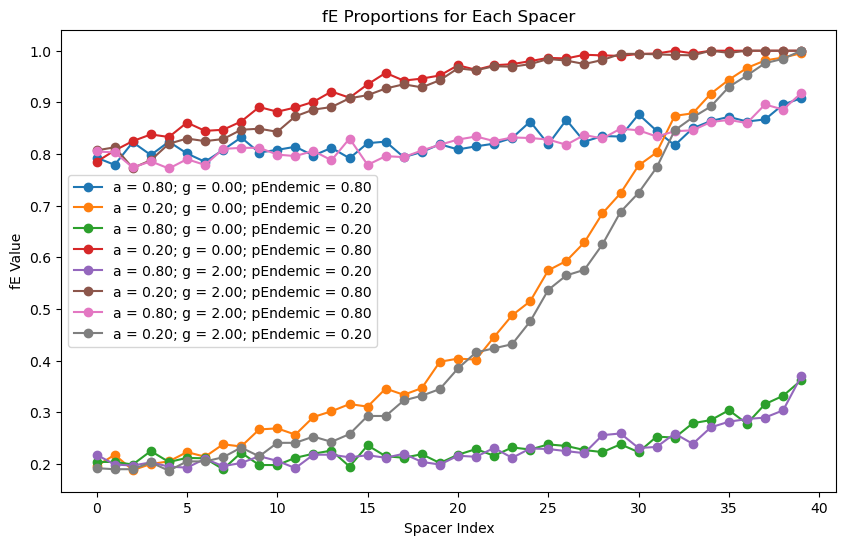

In [6]:
# Plot the fE results for each file
plt.figure(figsize=(10, 6))
for i in range(len(fEs)):
    plt.plot(fEs[i], label= extract_label(list(data_dict.keys())[i]), marker='o')

plt.title("fE Proportions for Each Spacer")
plt.xlabel("Spacer Index")
plt.ylabel("fE Value")
plt.legend()
plt.show()

We observe from this graph several aspects of how the proportion of endemic-target spacers evolves:
- The input parameter pEndemic defines the starting point of fE.
- The input parameter g does not influence the evolution of fE.
- The input parameter a defines the evolution of fE. When a is low (0.2) endemic spacers are favored, so the curve of fE increases early and more than on the other case (large a).

## Study different g values

In [7]:
import glob
import pandas as pd

def load_file(file_path):
    data = pd.read_csv(file_path, delim_whitespace=True, skiprows=5, dtype={'efficacy': 'str'})
    data = data.iloc[:, :-1]
    data['efficacy'] = data['efficacy'].astype(float)
    return data

# Specify the folder path and file pattern
folder_path = "/Users/jimenamartinreina/Documents/MASTER/PRÁCTICAS+TFM/MODELO/OUTPUTS/090125/"
file_pattern = "OutputFile_*.txt"

# Get a list of all files matching the pattern
file_paths = glob.glob(folder_path + file_pattern)
data_dict = {file_path: load_file(file_path) for file_path in file_paths}

# Verify data
for file, data in data_dict.items():
    print(f"Data for {file}:\n", data)

Data for /Users/jimenamartinreina/Documents/MASTER/PRÁCTICAS+TFM/MODELO/OUTPUTS/090125/OutputFile_0.50_6.67_0.50.txt:
       beta      age  efficacy  fitness  endemicBeta  epidemicBeta
0   0.7571    0.000    0.7645   0.7252       0.9999        0.5191
1   0.7508    1.010    0.6935   0.7185       0.9999        0.4956
2   0.7515    2.033    0.7623   0.7166       0.9999        0.5158
3   0.7378    3.079    0.6984   0.7080       0.9999        0.4789
4   0.7433    4.133    0.7705   0.6924       0.9999        0.5065
5   0.7298    5.192    0.7111   0.6633       0.9999        0.4854
6   0.7333    6.263    0.6932   0.5689       0.9999        0.4862
7   0.7447    7.364    0.6796   0.4224       0.9999        0.5035
8   0.7480    8.493    0.6774   0.3537       0.9999        0.5020
9   0.7381    9.662    0.6400   0.3166       0.9999        0.4945
10  0.7455   10.885    0.6460   0.3044       0.9999        0.5010
11  0.7414   12.142    0.5331   0.2870       0.9999        0.5150
12  0.7519   13.435    

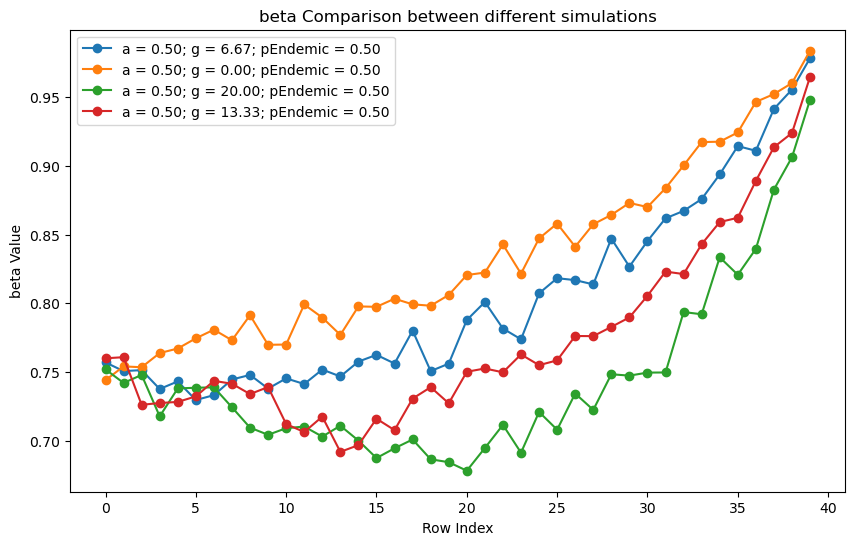

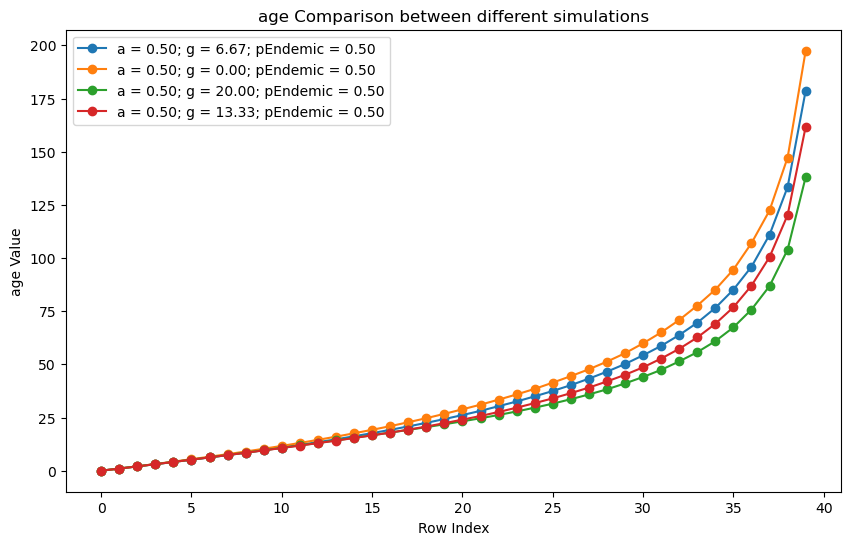

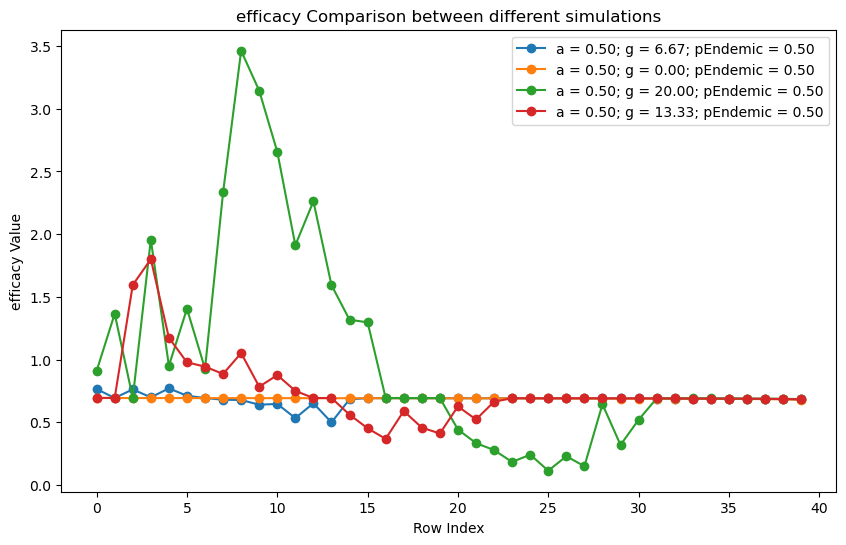

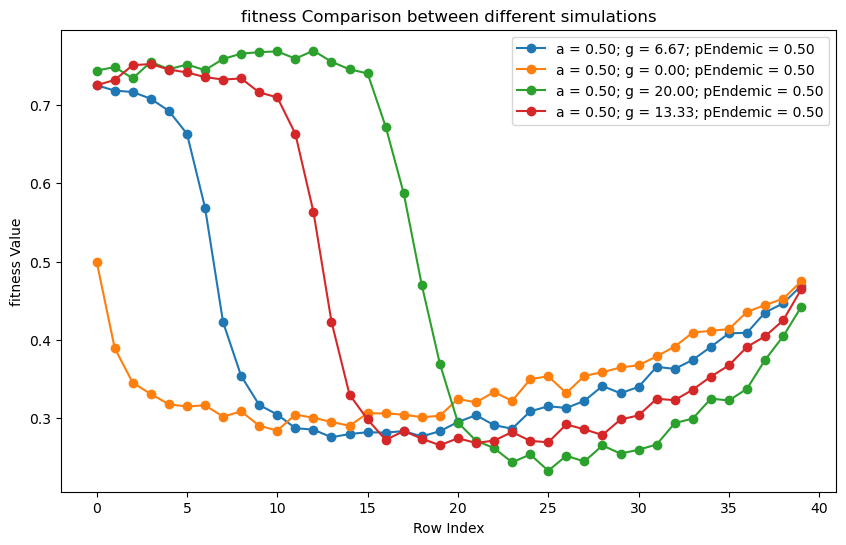

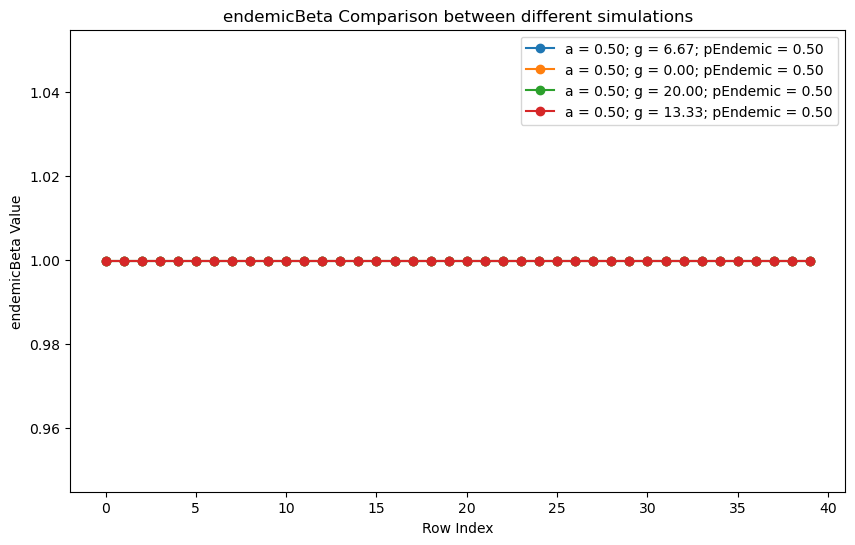

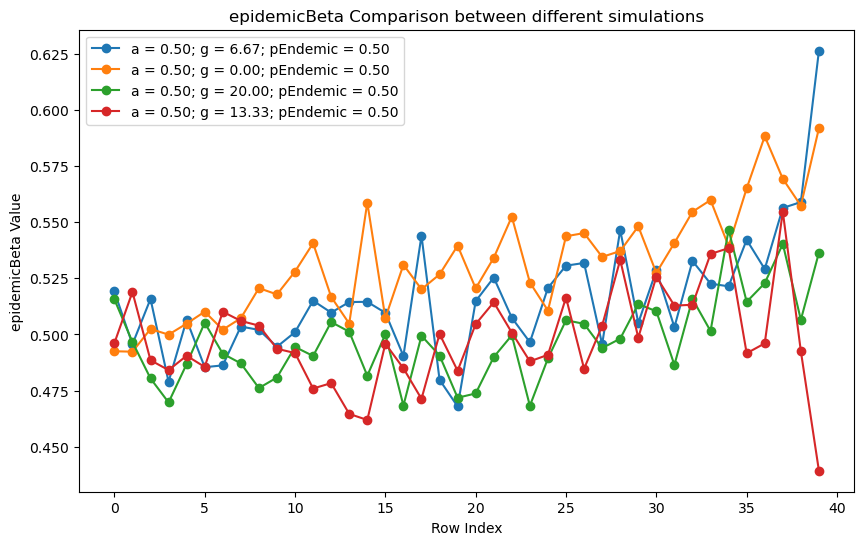

In [8]:
# Loop over each column
for column in columns:
    plt.figure(figsize=(10, 6))
    
    # Loop over each file and plot the column's data
    for file_name, data in data_dict.items():
        label = extract_label(file_name)
        plt.plot(data.index, data[column], label=label, marker='o')
    
    # Adding title and labels
    plt.title(f'{column} Comparison between different simulations')
    plt.xlabel('Row Index')
    plt.ylabel(f'{column} Value')
    plt.legend()
    
    # Show the plot for the current column
    plt.show()

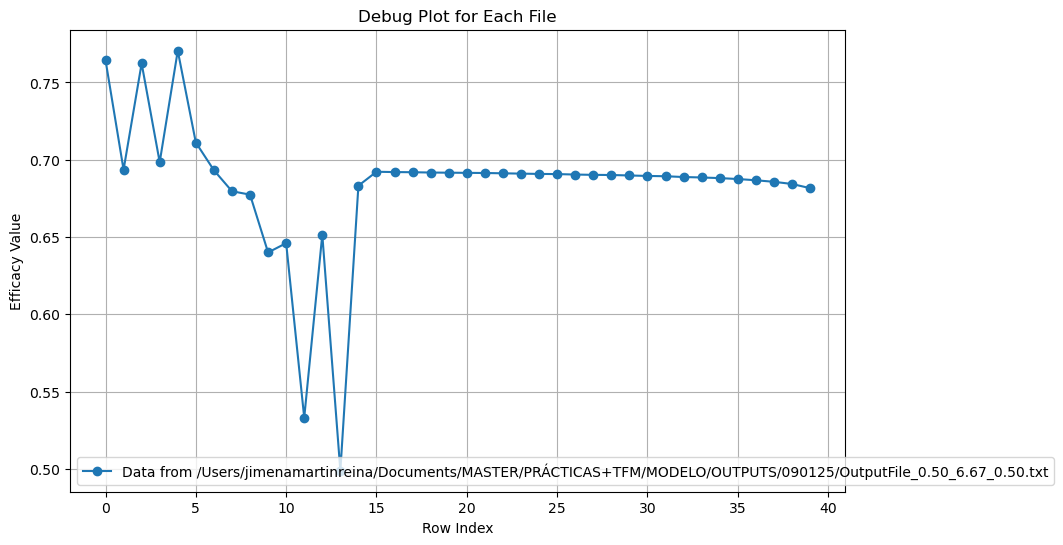

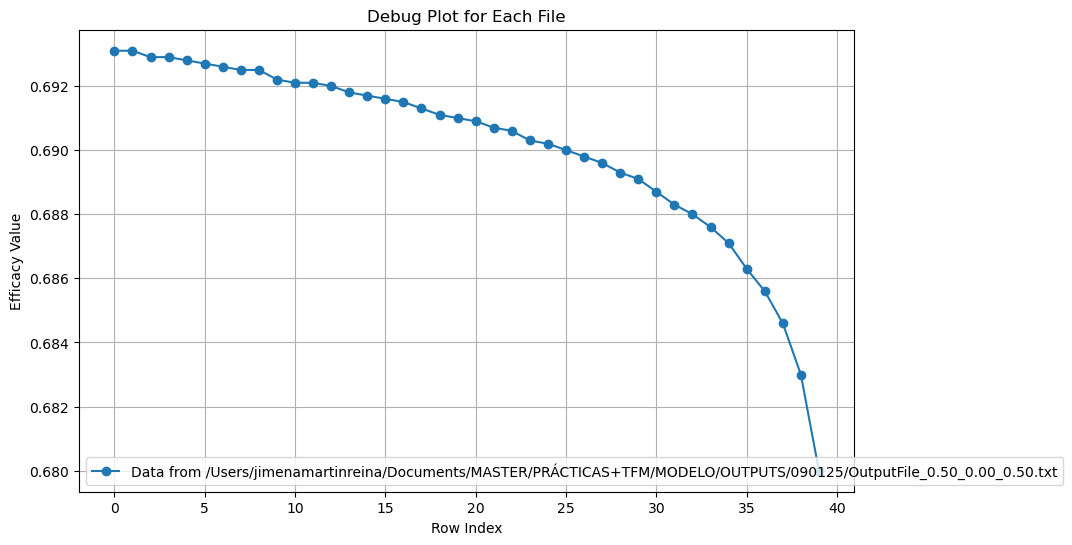

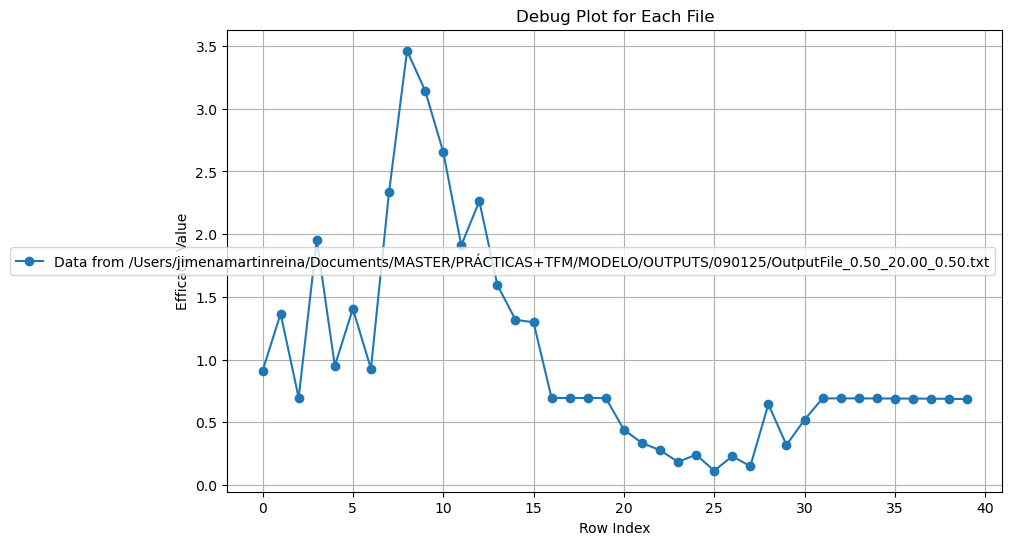

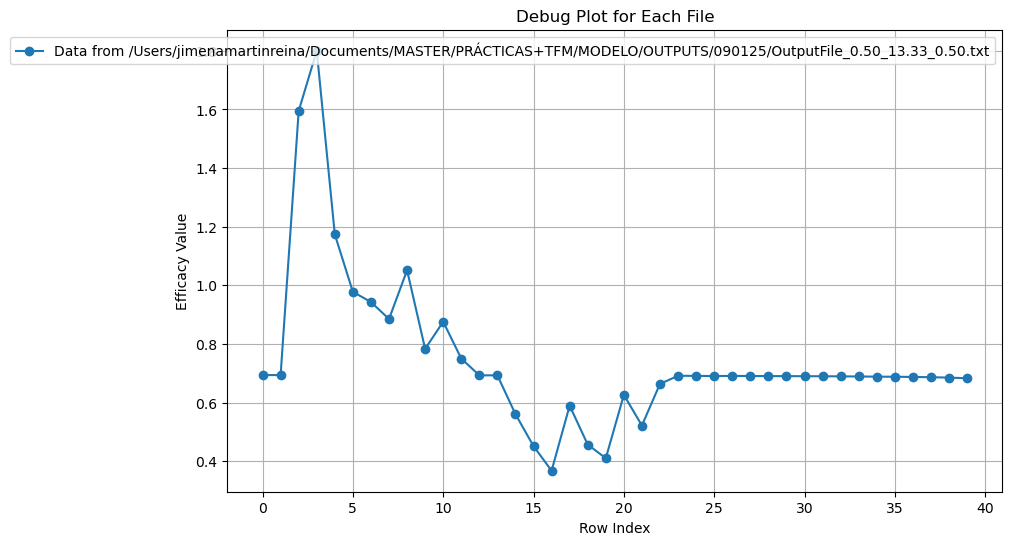

In [9]:
# UNA GRÁFICA PARA CADA ARCHIVO

for file_name, data in data_dict.items():
    plt.figure(figsize=(10, 6))
    plt.plot(data.index, data['efficacy'], marker='o', label=f"Data from {file_name}")
    plt.title("Debug Plot for Each File")
    plt.xlabel("Row Index")
    plt.ylabel("Efficacy Value")
    plt.legend()
    plt.grid(True)
    plt.show()

File: /Users/jimenamartinreina/Documents/MASTER/PRÁCTICAS+TFM/MODELO/OUTPUTS/090125/OutputFile_0.50_6.67_0.50.txt
  Max Left: 0, Value Max Left: 0.7252, Max Right: 39, Value Max Right: 0.4689
  Ratio of Left to Right Peak: 1.5466
  Minpoint : 13, Value : 0.2754
  Midpoint Left: 0.5003, Midpoint Right: 0.3721
  Euclidean distance between midpoints: 26.3467


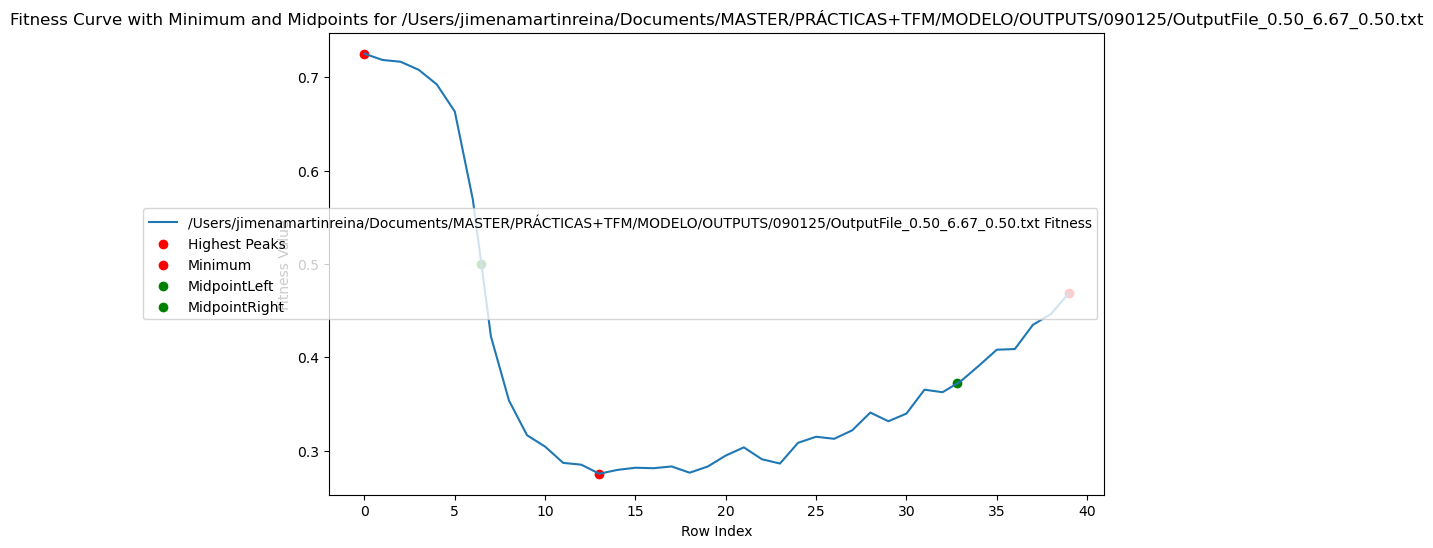

File: /Users/jimenamartinreina/Documents/MASTER/PRÁCTICAS+TFM/MODELO/OUTPUTS/090125/OutputFile_0.50_0.00_0.50.txt
  Max Left: 0, Value Max Left: 0.5, Max Right: 39, Value Max Right: 0.4745
  Ratio of Left to Right Peak: 1.0537
  Minpoint : 10, Value : 0.2839
  Midpoint Left: 0.3920, Midpoint Right: 0.3792
  Euclidean distance between midpoints: 30.0562


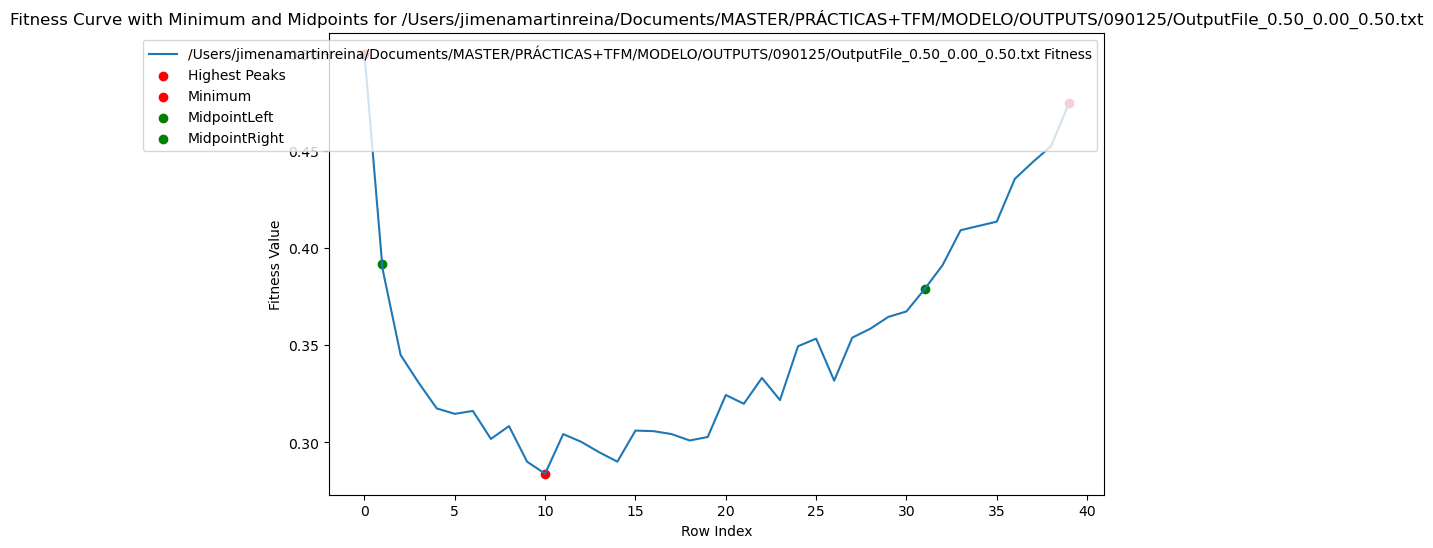

File: /Users/jimenamartinreina/Documents/MASTER/PRÁCTICAS+TFM/MODELO/OUTPUTS/090125/OutputFile_0.50_20.00_0.50.txt
  Max Left: 12, Value Max Left: 0.7694, Max Right: 39, Value Max Right: 0.4418
  Ratio of Left to Right Peak: 1.7415
  Minpoint : 25, Value : 0.2326
  Midpoint Left: 0.5010, Midpoint Right: 0.3372
  Euclidean distance between midpoints: 18.2596


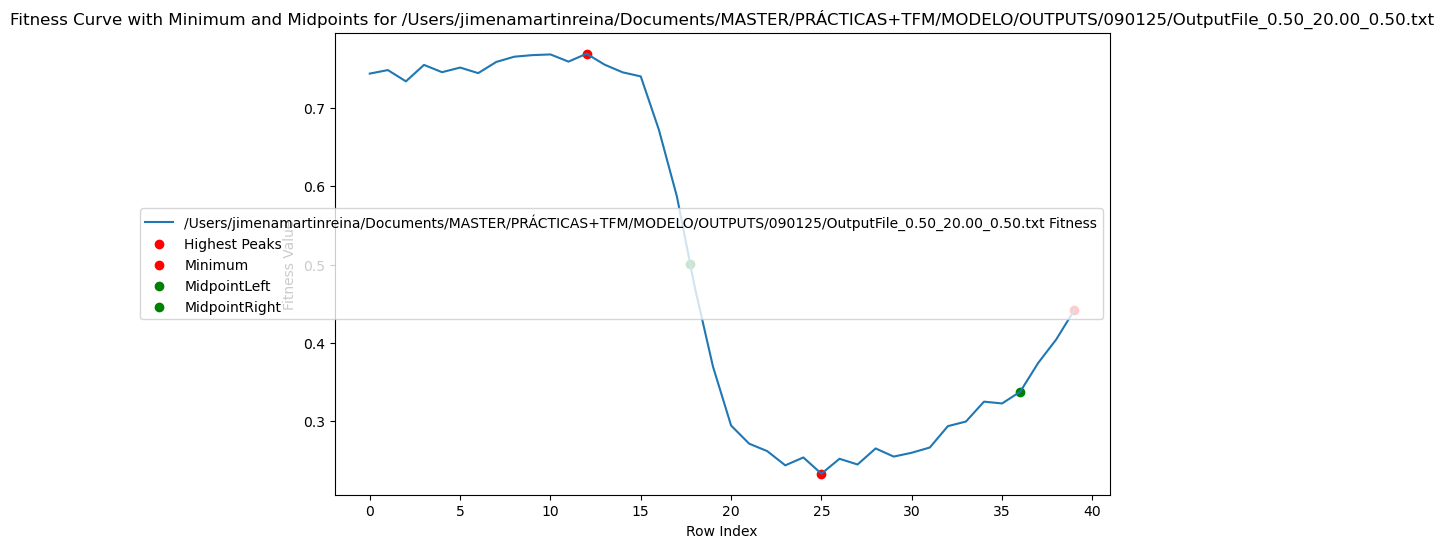

File: /Users/jimenamartinreina/Documents/MASTER/PRÁCTICAS+TFM/MODELO/OUTPUTS/090125/OutputFile_0.50_13.33_0.50.txt
  Max Left: 3, Value Max Left: 0.7523, Max Right: 39, Value Max Right: 0.4644
  Ratio of Left to Right Peak: 1.6199
  Minpoint : 19, Value : 0.2652
  Midpoint Left: 0.5088, Midpoint Right: 0.3648
  Euclidean distance between midpoints: 22.4365


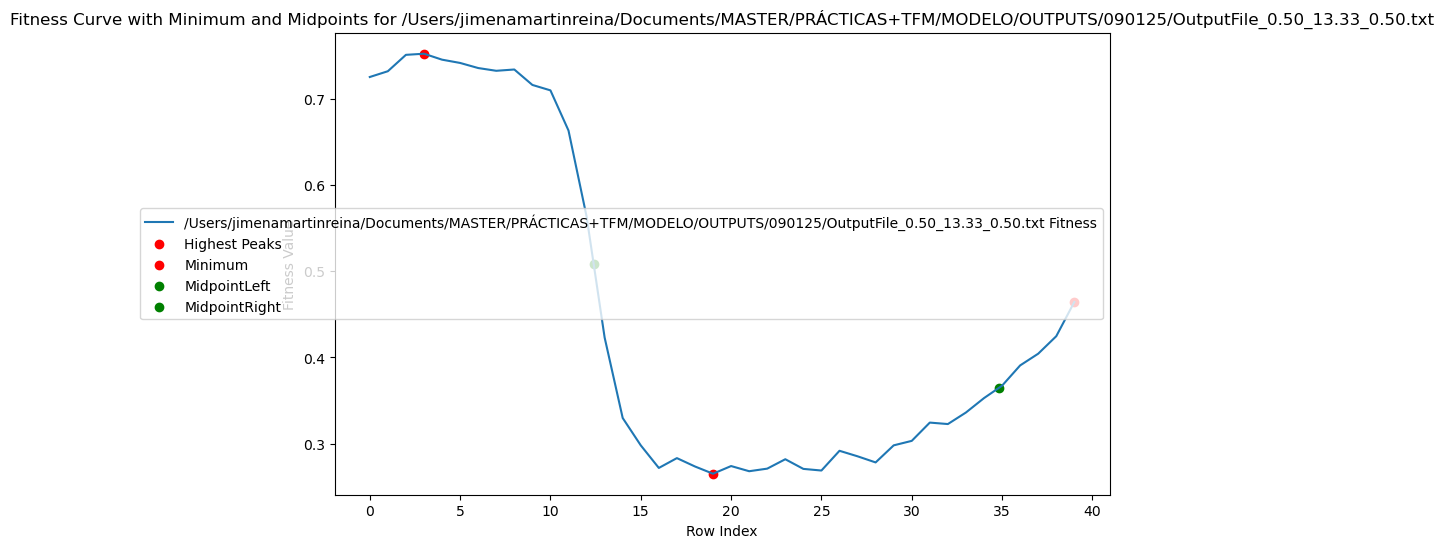

In [10]:
# Define a function to load the file and find the two highest peaks, including endpoints
# Loop over each file, calculate the minimum, midpoints, and plot the results

for file_path in file_paths:
    # Load fitness data again for plotting
    data = pd.read_csv(file_path, delim_whitespace=True, skiprows=5)
    fitness = data['fitness']
    x_values = np.arange(len(fitness))  # Create an array of x values (indices of the fitness array)

    # Calculate maxima
    min_point, ratio, left_peak, right_peak, left_peak_value, right_peak_value = calculate_peak_ratio_including_endpoints(file_path)

    # Calculate midpoints for left and right of the minimum
    midpoint_left = (fitness[min_point[0]] + left_peak_value) / 2
    midpoint_right = (fitness[min_point[0]] + right_peak_value) / 2
    
    # Find the indices of midpoints using interpolation
    midpoint_left_index = find_interpolated_index(x_values, fitness, midpoint_left) if midpoint_left is not None else None
    midpoint_right_index = find_interpolated_index_reverse(x_values, fitness, midpoint_right) if midpoint_right is not None else None
    # Calculate Euclidean distance between midpoints
    p = [midpoint_left_index, midpoint_left] 
    q = [midpoint_right_index, midpoint_right] 
    
    # Print the results
    print(f"File: {file_path}")
    print(f"  Max Left: {left_peak}, Value Max Left: {left_peak_value}, Max Right: {right_peak}, Value Max Right: {right_peak_value}")
    if ratio is not None:
        print(f"  Ratio of Left to Right Peak: {ratio:.4f}")
    else:
        print(f"File: {file_path} has an issue with the peak values; cannot calculate ratio.")
    print(f"  Minpoint : {min_point[0]}, Value : {fitness[min_point[0]]}")
    print(f"  Midpoint Left: {midpoint_left:.4f}, Midpoint Right: {midpoint_right:.4f}")
    print(f"  Euclidean distance between midpoints: {math.dist(p, q):.4f}")
    
    # Plotting the fitness curve with the marked minimum and midpoints
    plt.figure(figsize=(10, 6))
    plt.plot(fitness, label=f'{file_path} Fitness')
    
    # Plot maxima, minimum and midpoints (if valid)
    if left_peak is not None and right_peak is not None:
        plt.scatter([left_peak, right_peak], [fitness[left_peak], fitness[right_peak]], 
                    color='red', label='Highest Peaks')
    if min_point is not None:
        plt.scatter(min_point, fitness[min_point], color='red', label='Minimum')
    if midpoint_left is not None:
        plt.scatter(midpoint_left_index, midpoint_left, color='green', label='MidpointLeft')
    if midpoint_right is not None:
        plt.scatter(midpoint_right_index, midpoint_right, color='green', label='MidpointRight')

    plt.title(f"Fitness Curve with Minimum and Midpoints for {file_path}")
    plt.xlabel("Row Index")
    plt.ylabel("Fitness Value")
    plt.legend()
    plt.show()


In [11]:
# Initialize lists to store the beta values for each file
endemicBetas = []
epidemicBetas = []
betas = []

# Iterate over the dictionary to collect the 'endemicBeta', 'epidemicBeta', and 'beta' columns
for key, data in data_dict.items():
    endemicBetas.append(data['endemicBeta'])
    epidemicBetas.append(data['epidemicBeta'])
    betas.append(data['beta'])

# Keep results of fE (proportion of endemic-virus-target spacers in each position of the array)
fEs = []

# Calculate fE for each file
for i in range(len(data_dict)): 
    fE = (betas[i] - epidemicBetas[i]) / (endemicBetas[i] - epidemicBetas[i])
    fEs.append(fE)
#    print(f"fE for {list(data_dict.keys())[i]}:\n {fE}") #to verify results


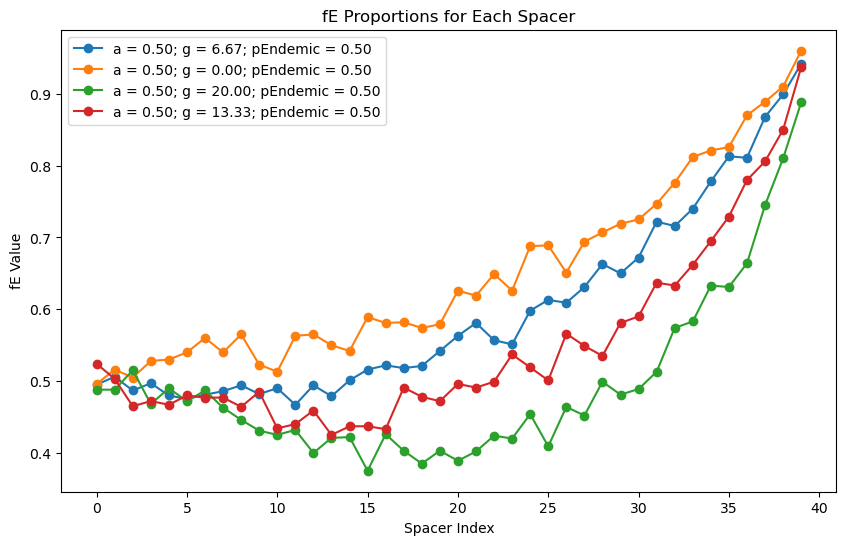

In [12]:
# Plot the fE results for each file
plt.figure(figsize=(10, 6))
for i in range(len(fEs)):
    plt.plot(fEs[i], label= extract_label(list(data_dict.keys())[i]), marker='o')

plt.title("fE Proportions for Each Spacer")
plt.xlabel("Spacer Index")
plt.ylabel("fE Value")
plt.legend()
plt.show()

### References
https://stackoverflow.com/questions/59163774/python-how-to-find-and-visually-mark-the-local-minima-of-a-sequence

https://www.w3schools.com/python/ref_math_dist.asp --> Euclidean distance between two points